In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('retail_pricing_final.csv', header=0)


df.columns = [
    'product_id', 'product_category_name', 'month_year',
    'unit_price', 'lag_price', 'qty', 'lag_qty',
    'comp_1', 'comp_2', 'comp_3',
    'pct_price_change', 'pct_demand_change',
    'avg_comp_price', 'price_vs_competitor'
]

In [3]:
print(df.shape)
print(df.columns.tolist())

df.head()

df.dtypes

df.isnull().sum()

(321, 14)
['product_id', 'product_category_name', 'month_year', 'unit_price', 'lag_price', 'qty', 'lag_qty', 'comp_1', 'comp_2', 'comp_3', 'pct_price_change', 'pct_demand_change', 'avg_comp_price', 'price_vs_competitor']


product_id               0
product_category_name    0
month_year               0
unit_price               0
lag_price                0
qty                      0
lag_qty                  0
comp_1                   0
comp_2                   0
comp_3                   0
pct_price_change         0
pct_demand_change        0
avg_comp_price           0
price_vs_competitor      0
dtype: int64

In [4]:
# Calculate price elasticity per product
elasticity = df.groupby(['product_id', 'product_category_name']).apply(
    lambda x: x['pct_demand_change'].median() / x['pct_price_change'].median(),
    include_groups=False
).reset_index()

elasticity.columns = ['product_id', 'product_category_name', 'elasticity']
elasticity['elasticity'] = elasticity['elasticity'].round(4)

print(elasticity.shape)
elasticity.head(10)

(49, 3)


,product_id,product_category_name,elasticity
0,bed1,bed_bath_table,-16.9802
1,bed2,bed_bath_table,35.5601
2,bed3,bed_bath_table,-19.1597
3,bed4,bed_bath_table,-9.7615
4,computers1,computers_accessories,-7.0256
5,computers2,computers_accessories,27.9226
6,computers3,computers_accessories,2.3387
7,computers4,computers_accessories,-3.4286
8,computers5,computers_accessories,-1223.4212
9,computers6,computers_accessories,-706.7033


In [5]:
# Remove extreme outliers
elasticity = elasticity[
    (elasticity['elasticity'] >= -50) & 
    (elasticity['elasticity'] <= 50)
]

In [6]:
# Classify each product
def classify(e):
    if e < -1:
        return 'Elastic'
    elif e == -1:
        return 'Unit Elastic'
    else:
        return 'Inelastic'

elasticity['classification'] = elasticity['elasticity'].apply(classify)

print(elasticity.shape)
print(elasticity['classification'].value_counts())
elasticity.head(10)

(25, 4)
classification
Elastic      13
Inelastic    12
Name: count, dtype: int64


,product_id,product_category_name,elasticity,classification
0,bed1,bed_bath_table,-16.9802,Elastic
1,bed2,bed_bath_table,35.5601,Inelastic
2,bed3,bed_bath_table,-19.1597,Elastic
3,bed4,bed_bath_table,-9.7615,Elastic
4,computers1,computers_accessories,-7.0256,Elastic
5,computers2,computers_accessories,27.9226,Inelastic
6,computers3,computers_accessories,2.3387,Inelastic
7,computers4,computers_accessories,-3.4286,Elastic
10,consoles1,consoles_games,2.1183,Inelastic
11,consoles2,consoles_games,2.2941,Inelastic


In [7]:
# Add recommendation column
def recommend(row):
    e = row['elasticity']
    if e < -1:
        return 'Discount freely'
    elif e > 1:
        return 'Premium product — do not discount'
    else:
        return 'Discount carefully'

elasticity['recommendation'] = elasticity.apply(recommend, axis=1)

print(elasticity['recommendation'].value_counts())
elasticity.head(10)

recommendation
Discount freely                      13
Premium product — do not discount    11
Discount carefully                    1
Name: count, dtype: int64


,product_id,product_category_name,elasticity,classification,recommendation
0,bed1,bed_bath_table,-16.9802,Elastic,Discount freely
1,bed2,bed_bath_table,35.5601,Inelastic,Premium product — do not discount
2,bed3,bed_bath_table,-19.1597,Elastic,Discount freely
3,bed4,bed_bath_table,-9.7615,Elastic,Discount freely
4,computers1,computers_accessories,-7.0256,Elastic,Discount freely
5,computers2,computers_accessories,27.9226,Inelastic,Premium product — do not discount
6,computers3,computers_accessories,2.3387,Inelastic,Premium product — do not discount
7,computers4,computers_accessories,-3.4286,Elastic,Discount freely
10,consoles1,consoles_games,2.1183,Inelastic,Premium product — do not discount
11,consoles2,consoles_games,2.2941,Inelastic,Premium product — do not discount


In [8]:
# Calculate optimal markdown for elastic products
def optimal_markdown(e):
    if e < -1:
        markdown = round(1 / (1 + abs(e)) * 100, 2)
        return min(markdown, 30)
    else:
        return 0

elasticity['recommended_discount'] = elasticity['elasticity'].apply(optimal_markdown)

# Format as percentage string
elasticity['recommended_discount'] = elasticity['recommended_discount'].apply(
    lambda x: f"{x}%" if x > 0 else "0%"
)

In [9]:
# Drop the old column if it exists
if 'optimal_markdown_pct' in elasticity.columns:
    elasticity = elasticity.drop(columns=['optimal_markdown_pct'])

elasticity.head(10)

elasticity.to_csv('elasticity_results.csv', index=False)

print(f"Total products: {len(elasticity)}")
print(f"Elastic products: {len(elasticity[elasticity['classification'] == 'Elastic'])}")
print(f"Inelastic products: {len(elasticity[elasticity['classification'] == 'Inelastic'])}")

Total products: 25
Elastic products: 13
Inelastic products: 12


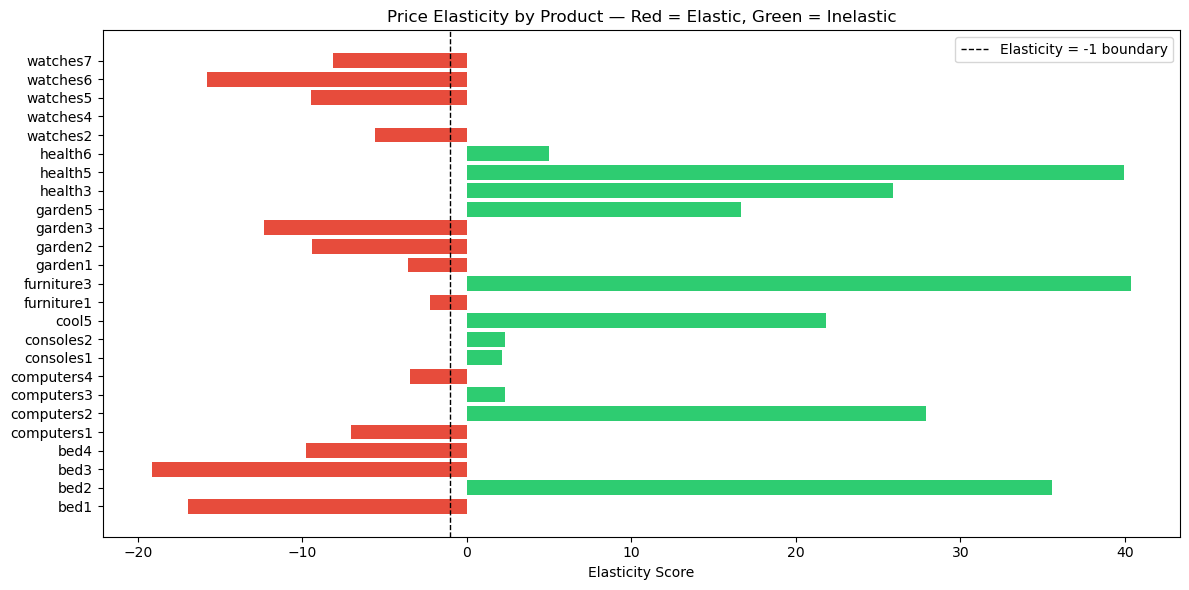

In [10]:
# Visualise elasticity scores by product
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

colors = elasticity['classification'].map({
    'Elastic': '#E74C3C',
    'Inelastic': '#2ECC71'
})

ax.barh(elasticity['product_id'], elasticity['elasticity'], color=colors)
ax.axvline(x=-1, color='black', linestyle='--', linewidth=1, label='Elasticity = -1 boundary')
ax.set_xlabel('Elasticity Score')
ax.set_title('Price Elasticity by Product — Red = Elastic, Green = Inelastic')
ax.legend()
plt.tight_layout()
plt.savefig('elasticity_chart.png', dpi=150)
plt.show()